# 4.5 — Likelihood & Cross-Entropy, at the computer

Do the **pen-and-paper worksheet first**. Payoff notebook: you'll plot the surprise curve, compute
the actual loss used to train every classifier and LLM, and watch likelihood find a hidden coin's
bias with no help from you.

Run each cell with **Shift+Enter**.

In [1]:
# Setup — run this first.
import sys
sys.path.append("../../../tools")

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## 1. The surprise curve

The whole lesson hangs on one function: $\text{surprise} = -\ln p$. Meet it properly:

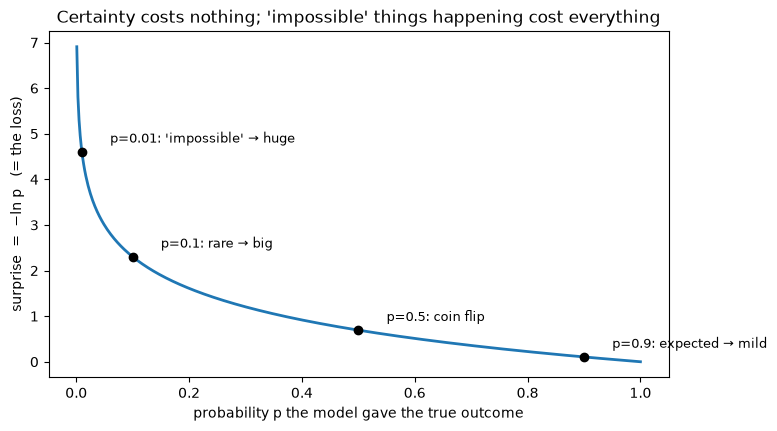

In [2]:
p = np.linspace(0.001, 1, 500)         # 500 probabilities from nearly-0 to 1

plt.figure(figsize=(8, 4.5))
plt.plot(p, -np.log(p), linewidth=2)   # np.log is the NATURAL log (ln) — ML's default
for prob, note in [(0.9, "expected \u2192 mild"), (0.5, "coin flip"), (0.1, "rare \u2192 big"), (0.01, "'impossible' \u2192 huge")]:
    plt.plot(prob, -np.log(prob), "ko")
    plt.annotate(f"p={prob}: {note}", (prob, -np.log(prob)), xytext=(prob + 0.05, -np.log(prob) + 0.2), fontsize=9)
plt.xlabel("probability p the model gave the true outcome")
plt.ylabel("surprise  =  \u2212ln p   (= the loss)")
plt.title("Certainty costs nothing; 'impossible' things happening cost everything")
plt.show()

Flat and cheap on the right, a wall on the left. Training = pushing every true answer's $p$
rightward, out of the expensive zone.

## 2. Cross-entropy: the real loss, computed by you

PICK the truth's probability → LOG → NEGATE → average over the batch. Two rival models on the
same three photos (truths: cat, cat, dog):

In [3]:
# probability each model gave the TRUE class of each photo (the PICK step, already done):
model_A = np.array([0.7, 0.6, 0.8])     # humble, decent
model_B = np.array([0.99, 0.98, 0.02])  # cocky — and confidently WRONG on photo 3

for name, p_true in [("A (humble)", model_A), ("B (cocky) ", model_B)]:
    surprises = -np.log(p_true)                       # LOG + NEGATE, all three at once
    print(f"model {name}: per-photo losses {surprises.round(2)}  \u2192 mean loss {surprises.mean():.3f}")

# B is MORE accurate on 2 of 3 photos — and still loses badly. One confident miss
# (-ln 0.02 ≈ 3.9) outweighs two near-perfect hits. Cross-entropy teaches calibration:
# don't just be right, be honestly unsure when you might be wrong.

model A (humble): per-photo losses [0.36 0.51 0.22]  → mean loss 0.364
model B (cocky) : per-photo losses [0.01 0.02 3.91]  → mean loss 1.314


## 3. 🌀 Likelihood finds the truth by itself

Here's the wonder moment. I'll make a **hidden biased coin** and flip it 50 times. Then we ask
*every possible model at once*: "$p = 0.01$, how likely is this data? $p = 0.02$? … $p = 0.99$?"
— and plot the answers. No solving, no algebra. Just: score every candidate, look at the curve.

observed: 32 heads, 18 tails


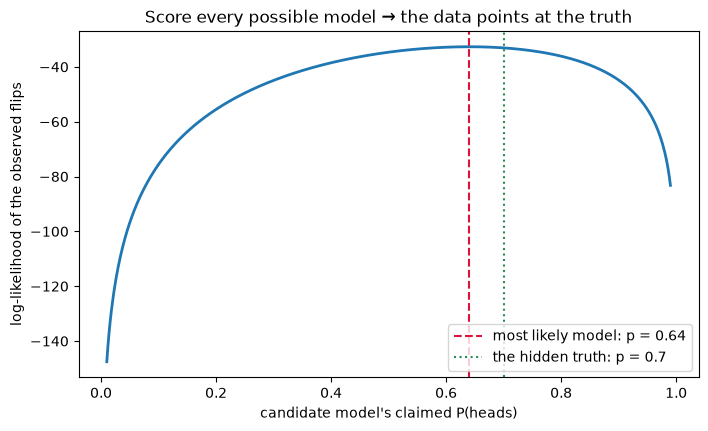

In [4]:
secret_p = 0.7                                     # the truth (pretend you can't see this line)
flips = rng.random(50) < secret_p                  # rng.random gives 0-1 floats; < turns them into
heads = flips.sum(); tails = 50 - heads            # True (heads) with probability secret_p
print(f"observed: {heads} heads, {tails} tails")

p_grid = np.linspace(0.01, 0.99, 500)              # every candidate model
# log-likelihood of the data under each candidate — logs turn the big product into a sum:
log_L = heads * np.log(p_grid) + tails * np.log(1 - p_grid)

best = p_grid[np.argmax(log_L)]                    # argmax = INDEX of the largest value

plt.figure(figsize=(8, 4.5))
plt.plot(p_grid, log_L, linewidth=2)
plt.axvline(best, color="crimson", linestyle="--", label=f"most likely model: p = {best:.2f}")
plt.axvline(secret_p, color="seagreen", linestyle=":", label=f"the hidden truth: p = {secret_p}")
plt.xlabel("candidate model's claimed P(heads)")
plt.ylabel("log-likelihood of the observed flips")
plt.title("Score every possible model \u2192 the data points at the truth")
plt.legend()
plt.show()

The peak lands almost exactly on the observed frequency of heads — and near the hidden truth.
**"Maximise likelihood" turned data into knowledge, mechanically.** Now the punchline of the whole
module: training a neural net = exactly this, at scale. The candidate models are weight settings,
the score is (negative) log-likelihood — cross-entropy — and instead of trying every candidate,
gradient descent (Module 3.5) walks downhill to the peak.

In [5]:
# YOUR TURN
#
# a) In the hidden-coin cell: set secret_p = 0.3 and re-run. Where's the peak now?
#
# b) Change 50 flips to 5000 (three edits: rng.random(...), the tails line, nothing else).
#    What happens to the SHARPNESS of the peak? Which unit of this module explains that?
#
# c) Worksheet 16 check — H, H, T. Score three candidate coins:
for p_model in [0.5, 2/3, 0.8]:
    L = p_model * p_model * (1 - p_model)
    print(f"p = {p_model:.3f}:  likelihood = {L:.4f},  -log-likelihood = {-np.log(L):.4f}")
# Confirm: highest L and lowest -log L crown the SAME winner. Try to beat 2/3.
#
# d) A 10-class model that shrugs gives every class p = 0.1. Print its loss -np.log(0.1)
#    and compare with np.log(10). (That's the 'knows nothing' score from the lesson.)

p = 0.500:  likelihood = 0.1250,  -log-likelihood = 2.0794
p = 0.667:  likelihood = 0.1481,  -log-likelihood = 1.9095
p = 0.800:  likelihood = 0.1280,  -log-likelihood = 2.0557


## 4. Module 4, complete

The chain you built: counting → distributions → sampling → **likelihood → cross-entropy**.
When Module 5's neural net trains, its loss line will be printing average surprise, $-\ln p$,
and you'll know precisely what every digit means.

---
*Done? Photograph your worksheet into `scans/inbox/`, then it's boss time:
`worksheets/06-boss-probability.md` — cold, on paper. Beat it and Module 5 (a neural net from
scratch) unlocks, with the Galton Board interlude as your reward.*